In [14]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt

In [3]:
# Traning set
import os
base_dir = "Dataset"
for a , b ,c in os.walk(base_dir):
    print(f"For {a} we have {len(b)} sub-folder having has {len(c)} images.")

For Dataset we have 2 sub-folder having has 0 images.
For Dataset\test we have 5 sub-folder having has 0 images.
For Dataset\test\Cancer we have 0 sub-folder having has 20 images.
For Dataset\test\Cassiopeia we have 0 sub-folder having has 23 images.
For Dataset\test\Centaurus we have 0 sub-folder having has 25 images.
For Dataset\test\Leo we have 0 sub-folder having has 59 images.
For Dataset\test\Orian we have 0 sub-folder having has 61 images.
For Dataset\train we have 5 sub-folder having has 0 images.
For Dataset\train\Cancer we have 0 sub-folder having has 80 images.
For Dataset\train\Cassiopeia we have 0 sub-folder having has 95 images.
For Dataset\train\Centaurus we have 0 sub-folder having has 104 images.
For Dataset\train\Leo we have 0 sub-folder having has 239 images.
For Dataset\train\Orian we have 0 sub-folder having has 245 images.


In [21]:
# making test images 
import shutil
import random

Target_foler_name = os.listdir(base_dir+ "/train")

train_path = os.path.join(base_dir , "train")
test_path = os.path.join(base_dir , "test")

for folder_name in Target_foler_name:
    
    train_subfolder = os.path.join(train_path , folder_name)
    test_subfolder = os.path.join(test_path , folder_name)
    
    os.makedirs(test_subfolder , exist_ok= False)
    
    images = [f for f in os.listdir(train_subfolder) if os.path.isfile(os.path.join(train_subfolder , f))]
    
    # Select randomly 20%
    num_of_img_tranfer = max(1 , int(len(images)*0.2))
    img_2_tranfer = random.sample(images , k = num_of_img_tranfer)
    
    # Tranfer file from train to test
    for img in img_2_tranfer:
        src = os.path.join(train_subfolder , img)
        des = os.path.join(test_subfolder , img)
        shutil.move(src , des)
        
    print(f"Created and populated {folder_name} in test folder.")

Created and populated Cancer in test folder.
Created and populated Cassiopeia in test folder.
Created and populated Centaurus in test folder.
Created and populated Leo in test folder.
Created and populated Orian in test folder.


In [4]:
# Now the dataset status
# Traning set
import os
base_dir = "Dataset"
for a , b ,c in os.walk(base_dir):
    print(f"For {a} we have {len(b)} sub-folder having has {len(c)} images.")

For Dataset we have 2 sub-folder having has 0 images.
For Dataset\test we have 5 sub-folder having has 0 images.
For Dataset\test\Cancer we have 0 sub-folder having has 20 images.
For Dataset\test\Cassiopeia we have 0 sub-folder having has 23 images.
For Dataset\test\Centaurus we have 0 sub-folder having has 25 images.
For Dataset\test\Leo we have 0 sub-folder having has 59 images.
For Dataset\test\Orian we have 0 sub-folder having has 61 images.
For Dataset\train we have 5 sub-folder having has 0 images.
For Dataset\train\Cancer we have 0 sub-folder having has 80 images.
For Dataset\train\Cassiopeia we have 0 sub-folder having has 95 images.
For Dataset\train\Centaurus we have 0 sub-folder having has 104 images.
For Dataset\train\Leo we have 0 sub-folder having has 239 images.
For Dataset\train\Orian we have 0 sub-folder having has 245 images.


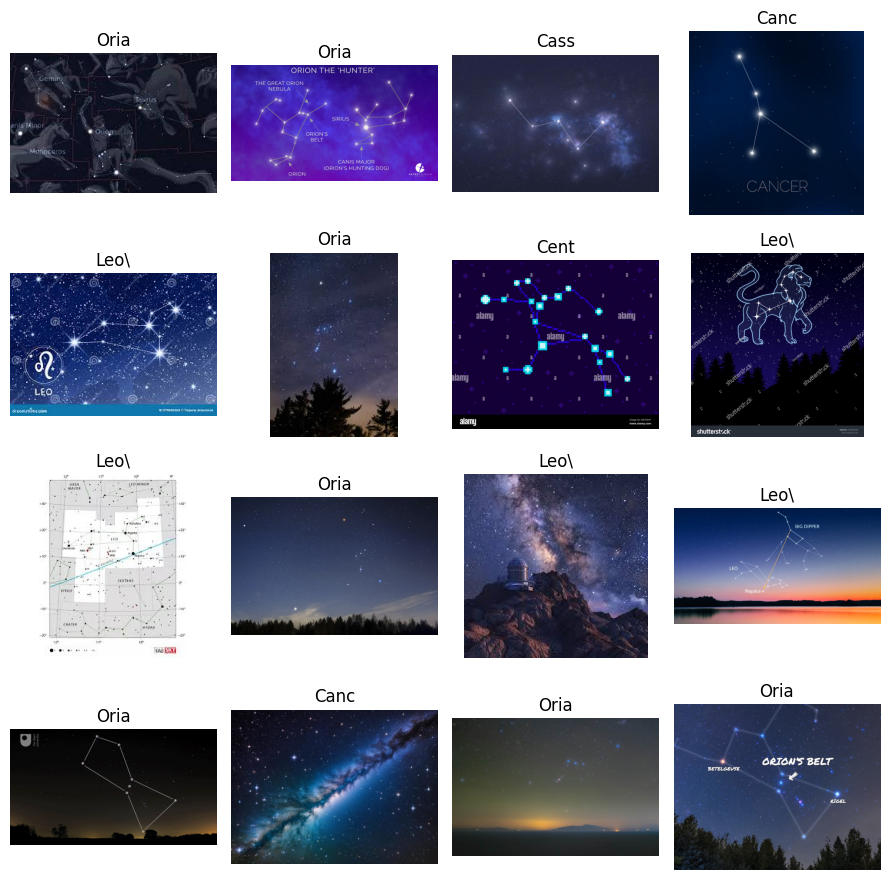

In [16]:
# Visualise some data 
from glob import glob
from PIL import Image
import random

train_dir = "Dataset/train"
test_dir = "Dataset/test"

fig = plt.figure(figsize=(9 , 9))
row , col = 4 , 4
img_list = glob(train_dir + "/*/*.jpg")

for i in range(row*col):
    
    random_img = random.sample(img_list , k = 1)
    
    img = Image.open(random_img[0])
    plt.subplot(row , col , i+1)
    plt.imshow(img)
    plt.title(random_img[0].split('/')[1][6:10])
    plt.axis("off")
    plt.tight_layout()

In [17]:
# Transforming the data
from torch.utils.data import DataLoader 
from torchvision import transforms

data_tranform = transforms.Compose([
    transforms.Resize((224 , 224) , interpolation=transforms.InterpolationMode.NEAREST),
    transforms.TrivialAugmentWide(num_magnitude_bins= 3),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.485, 0.456, 0.406] , std=[0.229,
                            0.224, 0.225])
])

In [18]:
# Importing the data
from torchvision import datasets

train_data = datasets.ImageFolder(train_dir , 
                                  transform= data_tranform ,
                                  target_transform= None)
test_data = datasets.ImageFolder(test_dir , 
                                  transform= data_tranform ,
                                  target_transform= None)

In [19]:
train_data.class_to_idx, test_data.class_to_idx

({'Cancer': 0, 'Cassiopeia': 1, 'Centaurus': 2, 'Leo': 3, 'Orian': 4},
 {'Cancer': 0, 'Cassiopeia': 1, 'Centaurus': 2, 'Leo': 3, 'Orian': 4})

In [70]:
# VGG16 Model

class CustomeVGG16(nn.Module):
    def __init__(self , out_dim , in_dim):
        super().__init__()
        self.out_dim = out_dim
        self.in_dim = in_dim
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels= self.in_dim , out_channels= 64 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= 64 , out_channels= 64 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= (2,2) , stride=2)    
        )
        
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels= 64 , out_channels= 128 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= 128 , out_channels= 128 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= (2,2) , stride=2)    
        )
        
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(in_channels= 128 , out_channels= 256 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= 256 , out_channels= 256 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= 256 , out_channels= 256 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= (2,2) , stride=2)    
        )
        self.conv_block_4 = nn.Sequential(
            nn.Conv2d(in_channels= 256 , out_channels= 512 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= 512 , out_channels= 512 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= 512 , out_channels= 512 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= (2,2) , stride=2)    
        )
        
        self.conv_block_5 = nn.Sequential(
            nn.Conv2d(in_channels= 512 , out_channels= 512 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= 512 , out_channels= 512 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= 512 , out_channels= 512 , kernel_size=(3,3) , padding= 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= (2,2) , stride=2)    
        )
        
        self.classifier = nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features= 512*7*7 , out_features= 256),
          nn.ReLU(),
          nn.Linear(in_features=256 , out_features= 128),
          nn.ReLU(),
          nn.Linear(in_features=128 , out_features= self.out_dim)
        )
        
    def forward(self , features):
        out1 = self.conv_block_1(features)
        # print(out1.shape) 
        out2 = self.conv_block_2(out1)
        # print(out2.shape) 
        out3 = self.conv_block_3(out2)
        # print(out3.shape) 
        out4 = self.conv_block_4(out3)
        # print(out4.shape) 
        out5 = self.conv_block_5(out4)
        # print(out5.shape)
        final = self.classifier(out5)
        # print(final.shape)
        return final 
    

In [71]:
len(train_data.classes)

5

In [23]:
from torchinfo import summary
model = CustomeVGG16(out_dim=len(train_data.classes) , in_dim=3)

summary(model= model , input_size=(16 , 3 , 224 , 224))


torch.Size([16, 64, 112, 112])
torch.Size([16, 128, 56, 56])
torch.Size([16, 256, 28, 28])
torch.Size([16, 512, 14, 14])
torch.Size([16, 512, 7, 7])
torch.Size([16, 5])


Layer (type:depth-idx)                   Output Shape              Param #
CustomeVGG16                             [16, 5]                   --
├─Sequential: 1-1                        [16, 64, 112, 112]        --
│    └─Conv2d: 2-1                       [16, 64, 224, 224]        1,792
│    └─ReLU: 2-2                         [16, 64, 224, 224]        --
│    └─Conv2d: 2-3                       [16, 64, 224, 224]        36,928
│    └─ReLU: 2-4                         [16, 64, 224, 224]        --
│    └─MaxPool2d: 2-5                    [16, 64, 112, 112]        --
├─Sequential: 1-2                        [16, 128, 56, 56]         --
│    └─Conv2d: 2-6                       [16, 128, 112, 112]       73,856
│    └─ReLU: 2-7                         [16, 128, 112, 112]       --
│    └─Conv2d: 2-8                       [16, 128, 112, 112]       147,584
│    └─ReLU: 2-9                         [16, 128, 112, 112]       --
│    └─MaxPool2d: 2-10                   [16, 128, 56, 56]         --

In [75]:
# Hyperparamter
 
BATCH_SIZE = 16
LR = 0.01
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr = LR , weight_decay= 1e-7)
epochs = 2

In [25]:
# Create dataloder 
from torch.utils.data import DataLoader
train_dataloder = DataLoader(train_data , batch_size= BATCH_SIZE , shuffle= True)
test_dataloder = DataLoader(train_data , batch_size= BATCH_SIZE , shuffle= False)

In [64]:
img_batch , label = next(iter(train_dataloder))
img_batch.shape , label.shape

(torch.Size([16, 3, 224, 224]), torch.Size([16]))

In [65]:
len(train_data)/16 , len(train_dataloder)

(47.375, 48)

In [66]:
ans = model(img_batch)


torch.Size([16, 64, 112, 112])
torch.Size([16, 128, 56, 56])
torch.Size([16, 256, 28, 28])
torch.Size([16, 512, 14, 14])
torch.Size([16, 512, 7, 7])
torch.Size([16, 5])


In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [61]:
# Accuracy function
def acc_fun(y_pred , y_true):
    y_pred = torch.argmax(y_pred , dim = 1)
    correct = torch.eq(y_true , y_pred).int().sum()
    ans = correct/len(y_true)
    return ans*100

In [73]:
# Traning Loop
def traning_step(model , train_dataloder , loss_fn , optimizer , acc_fun , device):
    model = model.to(device)

    batch_loss , batch_acc = 0 , 0
    for img_batch , labels in train_dataloder:
        
        # traning Mode
        model.train()
        
        img_batch , labels = img_batch.to(device), labels.to(device)
        
        # Forward Prop
        out = model(img_batch)
        
        # Loss calculation
        loss = loss_fn(out , labels)
        batch_loss += loss
        
        # Accuracy Calculation
        acc = acc_fun(y_pred= out , y_true= labels)
        batch_acc += acc
        
        # Backward prop
        optimizer.zero_grad()
        loss.backward()
        
        # upadte the weights
        optimizer.step()
            
    return batch_loss/len(train_dataloder) , batch_acc/len(train_dataloder)
    

In [74]:
# Testing Loop

def testing_step(model , test_dataloder , loss_fn , acc_fun , device):
    model = model.to(device)
    model.eval()
    batch_loss , batch_acc = 0 , 0
    for batch_img_test , labels in test_dataloder:
        batch_img_test , labels = batch_img_test.to(device) , labels.to(device)
        
        # Forward pass
        out = model(batch_img_test)
        
        # Loss Caluclations
        loss = loss_fn(out , labels)
        batch_loss += loss
        
        # Accuacy Calculations
        acc = acc_fun(y_pred= out , y_true= labels)
        
    return batch_loss/len(test_dataloder) , batch_acc / len(test_dataloder)


In [78]:
# Model Traing
import tqdm
matrices = {"training loss" : [],
            "training acc" : [],
            "testing loss" : [],
            "testing acc" : []
            }

for epoch in tqdm.tqdm(range(epochs)):
    train_loss , train_acc = traning_step(model= model ,
                 train_dataloder= train_dataloder,
                 loss_fn= loss_fn,
                 optimizer= optimizer,
                 acc_fun= acc_fun,
                 device= device)
    test_loss , test_acc = testing_step(model= model,
                 test_dataloder=test_dataloder ,
                 loss_fn= loss_fn,
                 acc_fun= acc_fun,
                 device= device)
    
    # 4. Print out what's happening
    print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

    matrices["testing acc"].append(test_acc)
    matrices["testing loss"].append(test_loss)
    matrices["training acc"].append(train_acc),
    matrices["training loss"].append(train_loss)
    

  0%|          | 0/2 [00:00<?, ?it/s]

torch.Size([16, 64, 112, 112])
torch.Size([16, 128, 56, 56])
torch.Size([16, 256, 28, 28])
torch.Size([16, 512, 14, 14])
torch.Size([16, 512, 7, 7])
torch.Size([16, 5])
torch.Size([16, 64, 112, 112])
torch.Size([16, 128, 56, 56])
torch.Size([16, 256, 28, 28])
torch.Size([16, 512, 14, 14])
torch.Size([16, 512, 7, 7])
torch.Size([16, 5])
torch.Size([16, 64, 112, 112])
torch.Size([16, 128, 56, 56])
torch.Size([16, 256, 28, 28])
torch.Size([16, 512, 14, 14])
torch.Size([16, 512, 7, 7])
torch.Size([16, 5])
torch.Size([16, 64, 112, 112])
torch.Size([16, 128, 56, 56])
torch.Size([16, 256, 28, 28])
torch.Size([16, 512, 14, 14])
torch.Size([16, 512, 7, 7])
torch.Size([16, 5])


  0%|          | 0/2 [00:33<?, ?it/s]


KeyboardInterrupt: 